# 🚀 OVERVIEW (what you’re building)

You will implement:

1. Federated Learning (FL) setup
2. Logit-level poisoning attack
3. Behavior-based detection (logit consistency)
4. Comparison vs weight-based signals

# ⚠️ Before you start (discipline check)

If you:

* Skip logging → useless
* Skip baseline → meaningless
* Skip attack validation → fake result

Then don’t even start.

# 🧠 COLAB STRUCTURE

# 🟦 1. Setup

In [1]:
!pip install torch torchvision numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🟦 2. Dataset (MNIST)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


# 🟦 3. Split into clients (FL setup)

In [4]:
def split_clients(dataset, num_clients=5):
    data_per_client = len(dataset) // num_clients
    clients = []

    for i in range(num_clients):
        indices = list(range(i*data_per_client, (i+1)*data_per_client))
        clients.append(torch.utils.data.Subset(dataset, indices))

    return clients

clients = split_clients(trainset, num_clients=5)

# 🟦 4. Model (simple but enough)

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)  # logits (IMPORTANT)

# 🟦 5. Local training (normal client)

In [6]:
def train_local(model, dataset, epochs=1):
    model.train()
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = nn.CrossEntropyLoss()(logits, y)
            loss.backward()
            optimizer.step()

    return model.state_dict()

# 🟥 6. MALICIOUS CLIENT (logit poisoning)

In [7]:
def train_malicious(model, dataset, target_class=0, poison_weight=0.3, epochs=1):
    model.train()
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)

            # NORMAL LOSS
            loss = nn.CrossEntropyLoss()(logits, y)

            # 🔥 LOGIT MANIPULATION
            fake_targets = torch.full_like(y, target_class)

            # Encourage model to bias towards target class subtly
            poison_loss = nn.CrossEntropyLoss()(logits, fake_targets)

            total_loss = loss + poison_weight * poison_loss  # subtle

            total_loss.backward()
            optimizer.step()

    return model.state_dict()

# 🟦 7. Aggregation (FedAvg)

In [8]:
def aggregate(global_model, client_states):
    new_state = copy.deepcopy(global_model.state_dict())

    for key in new_state:
        new_state[key] = torch.stack(
            [client_states[i][key] for i in range(len(client_states))]
        ).mean(0)

    global_model.load_state_dict(new_state)
    return global_model

# 🟦 8. Evaluation

In [9]:
def test(model, dataset):
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=64)
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

# 🟥 9. LOGIT CONSISTENCY (YOUR CORE IDEA)

In [10]:
def logit_consistency(model, dataset, epsilon=0.1, samples=500):
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

    diffs = []
    count = 0

    for x, _ in loader:
        if count >= samples:
            break

        x = x.to(device)

        noise = torch.randn_like(x) * epsilon
        x_perturbed = x + noise

        with torch.no_grad():
            logits1 = model(x)
            logits2 = model(x_perturbed)

        diff = torch.norm(logits1 - logits2).item()
        diffs.append(diff)

        count += 1

    return np.mean(diffs)

# 🟦 10. Run Federated Training

In [11]:
def run_federated_training(num_rounds, num_clients, malicious_client_index=0, poison_weight=0.3, enable_malicious=True):
    global_model = Net().to(device)
    history = {'accuracy': [], 'consistency': [], 'weight_norm': []}

    for r in range(num_rounds):
        client_states = []

        for i in range(num_clients):
            local_model = copy.deepcopy(global_model)

            if enable_malicious and i == malicious_client_index:
                # malicious client
                state = train_malicious(local_model, clients[i], poison_weight=poison_weight)
            else:
                state = train_local(local_model, clients[i])

            client_states.append(state)

        global_model = aggregate(global_model, client_states)

        acc = test(global_model, testset)
        consistency = logit_consistency(global_model, testset)
        w_norm = weight_norm(global_model)

        history['accuracy'].append(acc)
        history['consistency'].append(consistency)
        history['weight_norm'].append(w_norm)

        print(f"Round {r+1}: Accuracy = {acc:.4f}, Consistency = {consistency:.4f}, Weight Norm = {w_norm:.4f}")

    return global_model, history

# Placeholder for weight_norm function to avoid errors before it's defined.
# It will be overwritten later.
def weight_norm(model):
    total = 0
    for p in model.parameters():
        total += torch.norm(p).item()
    return total

# Run with attack
print("\n--- Running Federated Training with Poisoning Attack ---")
attack_global_model, attack_history = run_federated_training(num_rounds=5, num_clients=5, enable_malicious=True)




--- Running Federated Training with Poisoning Attack ---
Round 1: Accuracy = 0.7583, Consistency = 0.1722, Weight Norm = 9.6094
Round 2: Accuracy = 0.8503, Consistency = 0.3118, Weight Norm = 10.8029
Round 3: Accuracy = 0.8728, Consistency = 0.4103, Weight Norm = 11.5166
Round 4: Accuracy = 0.8859, Consistency = 0.4746, Weight Norm = 11.9988
Round 5: Accuracy = 0.8925, Consistency = 0.5208, Weight Norm = 12.3572


# 🟦 11. Detection Results

In [12]:
consistency_score_poisoned = logit_consistency(attack_global_model, testset)

print("Logit Consistency Score (Poisoned Model):", consistency_score_poisoned)

Logit Consistency Score (Poisoned Model): 0.5120053299665451


# 🟦 12. Baseline (NO attack)

In [13]:
print("\n--- Running Federated Training without Attack (Baseline) ---")
clean_global_model, clean_history = run_federated_training(num_rounds=5, num_clients=5, enable_malicious=False)

consistency_score_clean = logit_consistency(clean_global_model, testset)

print("\nClean vs Poisoned consistency")
print(f"Clean Model Consistency: {consistency_score_clean:.4f}")
print(f"Poisoned Model Consistency: {consistency_score_poisoned:.4f}")


--- Running Federated Training without Attack (Baseline) ---
Round 1: Accuracy = 0.7857, Consistency = 0.1712, Weight Norm = 9.6321
Round 2: Accuracy = 0.8491, Consistency = 0.3169, Weight Norm = 10.8587
Round 3: Accuracy = 0.8736, Consistency = 0.4209, Weight Norm = 11.6041
Round 4: Accuracy = 0.8869, Consistency = 0.5034, Weight Norm = 12.1163
Round 5: Accuracy = 0.8939, Consistency = 0.5730, Weight Norm = 12.5035

Clean vs Poisoned consistency
Clean Model Consistency: 0.5531
Poisoned Model Consistency: 0.5120


# 📊 13. Plot (MANDATORY)

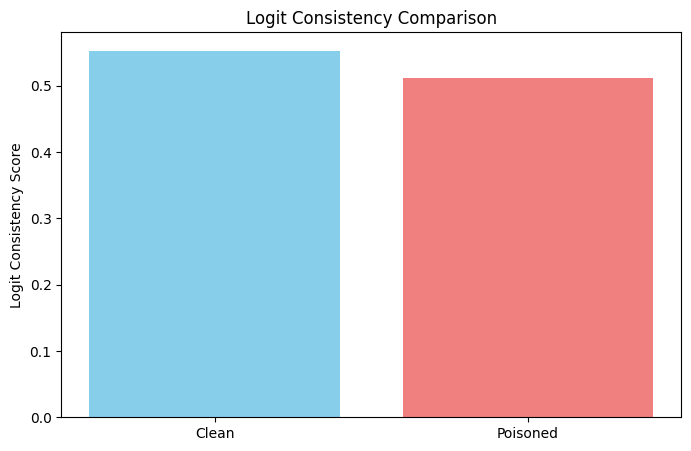

In [14]:
labels = ["Clean", "Poisoned"]
scores = [consistency_score_clean, consistency_score_poisoned]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores, color=['skyblue', 'lightcoral'])
plt.title("Logit Consistency Comparison")
plt.ylabel("Logit Consistency Score")
plt.show()

# 🧪 WHAT MAKES THIS “RESEARCH LEVEL”

If you stop here → average.

To level up:

## Add 1: Attack strength sweep


--- Running Attack Strength Sweep ---

Running with poison_weight = 0.1
Round 1: Accuracy = 0.7642, Consistency = 0.1667, Weight Norm = 9.6049
Round 2: Accuracy = 0.8512, Consistency = 0.3167, Weight Norm = 10.8133
Round 3: Accuracy = 0.8739, Consistency = 0.4135, Weight Norm = 11.5477
Round 4: Accuracy = 0.8851, Consistency = 0.4775, Weight Norm = 12.0443
Round 5: Accuracy = 0.8922, Consistency = 0.5322, Weight Norm = 12.4147

Running with poison_weight = 0.3
Round 1: Accuracy = 0.7736, Consistency = 0.1652, Weight Norm = 9.5681
Round 2: Accuracy = 0.8519, Consistency = 0.3021, Weight Norm = 10.7733
Round 3: Accuracy = 0.8719, Consistency = 0.4050, Weight Norm = 11.4974
Round 4: Accuracy = 0.8848, Consistency = 0.4679, Weight Norm = 11.9825
Round 5: Accuracy = 0.8914, Consistency = 0.5226, Weight Norm = 12.3442

Running with poison_weight = 0.5
Round 1: Accuracy = 0.7543, Consistency = 0.1755, Weight Norm = 9.6774
Round 2: Accuracy = 0.8504, Consistency = 0.3169, Weight Norm = 10.850

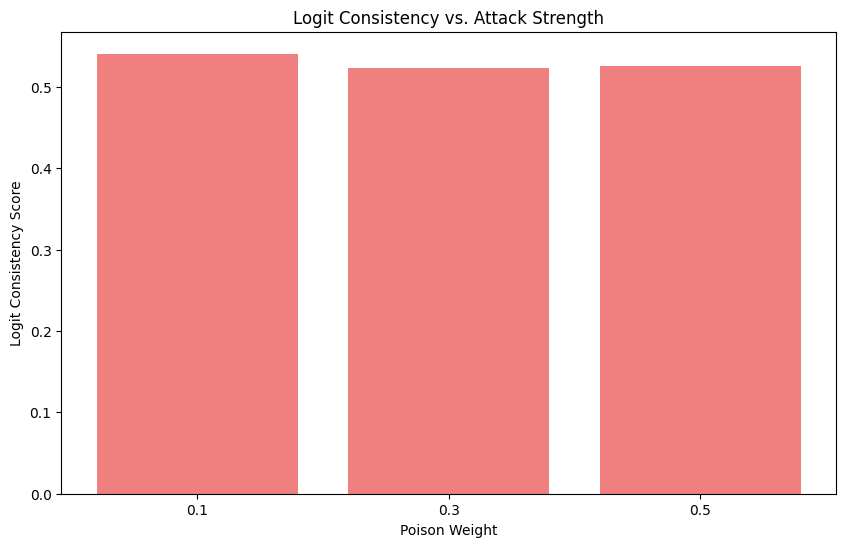

In [15]:
poison_weights = [0.1, 0.3, 0.5]
attack_sweep_results = {}

print("\n--- Running Attack Strength Sweep ---")
for pw in poison_weights:
    print(f"\nRunning with poison_weight = {pw}")
    model_pw, history_pw = run_federated_training(num_rounds=5, num_clients=5, poison_weight=pw, enable_malicious=True)
    attack_sweep_results[pw] = {
        'accuracy': history_pw['accuracy'][-1],
        'consistency': logit_consistency(model_pw, testset),
        'weight_norm': weight_norm(model_pw)
    }

print("\nAttack Strength Sweep Results:")
for pw, results in attack_sweep_results.items():
    print(f"Poison Weight {pw}: Accuracy={results['accuracy']:.4f}, Consistency={results['consistency']:.4f}, Weight Norm={results['weight_norm']:.4f}")

# Plotting sweep results for consistency
plt.figure(figsize=(10, 6))
plt.bar([str(pw) for pw in poison_weights], [attack_sweep_results[pw]['consistency'] for pw in poison_weights], color='lightcoral')
plt.title("Logit Consistency vs. Attack Strength")
plt.ylabel("Logit Consistency Score")
plt.xlabel("Poison Weight")
plt.show()

## Add 2: Compare with weight norm


Weight Norm (Clean Model): 12.5035
Weight Norm (Poisoned Model): 12.3572


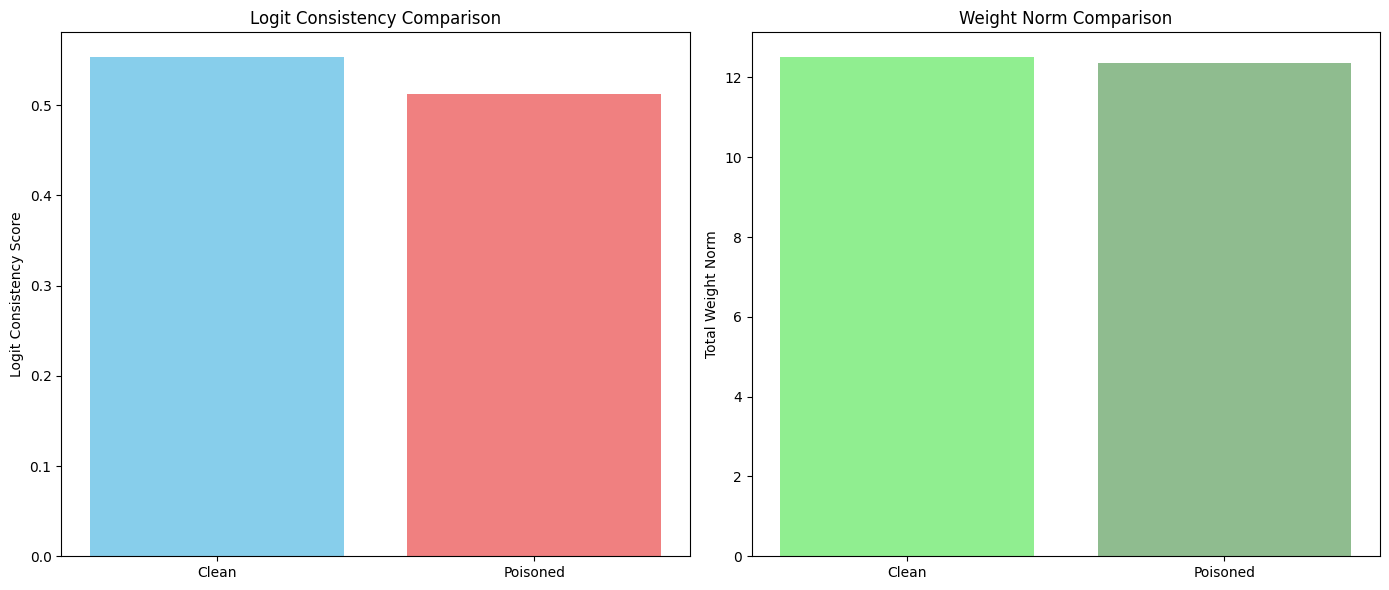

In [16]:
def weight_norm(model):
    total = 0
    for p in model.parameters():
        total += torch.norm(p).item()
    return total

# Get weight norms for clean and poisoned models
weight_norm_clean = weight_norm(clean_global_model)
weight_norm_poisoned = weight_norm(attack_global_model)

print(f"\nWeight Norm (Clean Model): {weight_norm_clean:.4f}")
print(f"Weight Norm (Poisoned Model): {weight_norm_poisoned:.4f}")

# Plotting comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Consistency plot
axes[0].bar(labels, scores, color=['skyblue', 'lightcoral'])
axes[0].set_title("Logit Consistency Comparison")
axes[0].set_ylabel("Logit Consistency Score")

# Weight norm plot
axes[1].bar(labels, [weight_norm_clean, weight_norm_poisoned], color=['lightgreen', 'darkseagreen'])
axes[1].set_title("Weight Norm Comparison")
axes[1].set_ylabel("Total Weight Norm")

plt.tight_layout()
plt.show()

Show:

* Weight norm ≈ same
* Consistency changes

## Add 3: Targeted accuracy


Targeted Prediction Rate for class 0 (Clean Model): 0.1039
Targeted Prediction Rate for class 0 (Poisoned Model): 0.1088


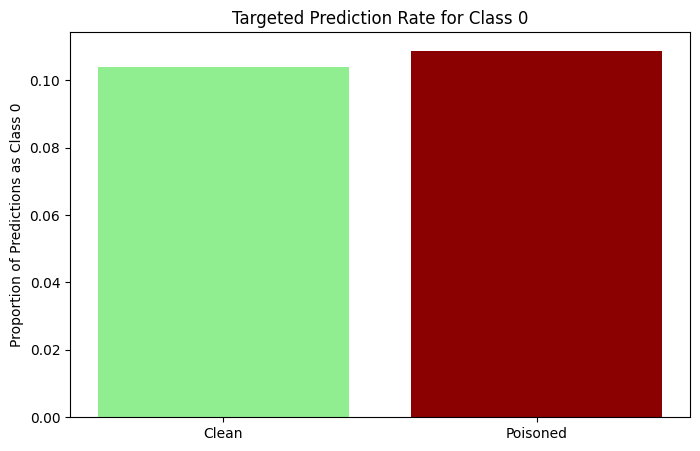

In [17]:
def targeted_accuracy(model, dataset, target_class=0):
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=64)
    targeted_correct = 0
    total_target_predictions = 0
    total_samples_with_target = 0 # To count how many samples actually have target class as true label

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            # For targeted accuracy, we want to see how many samples are predicted as the target class
            # among all samples, or specifically among samples of a certain true class (e.g., target_class)

            # Let's define it as: how often the model predicts the 'target_class' regardless of true label
            # And how many samples originally of a different class get misclassified as target_class

            # Count how many predictions are for the target_class
            targeted_correct += (preds == target_class).sum().item()
            total_target_predictions += y.size(0) # Total number of predictions made

            # Optionally, to measure the attack's effectiveness on misclassification:
            # How many *non-target_class* items are predicted as *target_class*
            non_target_indices = (y != target_class)
            misclassified_as_target = (preds[non_target_indices] == target_class).sum().item()
            total_non_target = non_target_indices.sum().item()

    # For simplicity, let's just show the proportion of samples predicted as the target class
    # A high value here for poisoned model indicates success, assuming target_class is a minority or specific class.
    # If the target_class is 0, this might naturally be high, so context is important.
    return targeted_correct / total_target_predictions if total_target_predictions > 0 else 0

target_class_to_poison = 0 # As used in train_malicious

# Targeted accuracy for clean model
targeted_acc_clean = targeted_accuracy(clean_global_model, testset, target_class=target_class_to_poison)
print(f"\nTargeted Prediction Rate for class {target_class_to_poison} (Clean Model): {targeted_acc_clean:.4f}")

# Targeted accuracy for poisoned model
targeted_acc_poisoned = targeted_accuracy(attack_global_model, testset, target_class=target_class_to_poison)
print(f"Targeted Prediction Rate for class {target_class_to_poison} (Poisoned Model): {targeted_acc_poisoned:.4f}")

# Plotting targeted accuracy
plt.figure(figsize=(8, 5))
plt.bar(labels, [targeted_acc_clean, targeted_acc_poisoned], color=['lightgreen', 'darkred'])
plt.title(f"Targeted Prediction Rate for Class {target_class_to_poison}")
plt.ylabel(f"Proportion of Predictions as Class {target_class_to_poison}")
plt.show()

Check:

* How often target class is predicted

# 🧠 Final Reality Check

If you execute this properly, you can say:

> “I demonstrate that logit-level poisoning introduces detectable behavioral inconsistencies even when parameter-level signals remain unchanged.”

That’s a **real research statement**.

# ⚡ Next move

If you’re serious:

Say:

> “Help me convert results into a paper/report”

And I’ll help you turn this into:

* proper writeup
* figures
* strong narrative

Right now: **build first. No shortcuts.**